# **Práctica Clustering**


## **Clustering**

*Clustering
El un método de *machine learning*, **no supervisados**, cuyo principal objetivo encontrar grupos de datos con patrones similares. Algunos de esos  
algoritmos son [**kmeans**](https://towardsdatascience.com/k-means-clustering-algorithm-applications-evaluation-methods-and-drawbacks-aa03e644b48a), [**mean sheaf**](https://www.geeksforgeeks.org/ml-mean-shift-clustering/) y [**DBScan**](https://www.kdnuggets.com/2020/04/dbscan-clustering-algorithm-machine-learning.html)  


## **Segmentación de imágenes médicas mediante técnicas de clustering**


Para esta práctica vuestro grupo utilizará la siguiente 
[base de datos](https://drive.google.com/file/d/1HuOf5CWxZRsWr-37TIxP5msAqmgsYE4o/view?usp=sharing). Esta base de datos contiene imágenes BMP de tomografías de cerebro.

Tenga en cuanta que as imágenes, a color, son cubos de m x n x k , donde m es el número de filas, n el número de columnas y K=3, en caso de imágenes a color, es el número de canales de la imagen.  Por otro lado, cada pixel, se representa, generalmente como un vector de tamaño k, donde k es el número canales. Luego, podemos pensar en una imagen como un conjunto de puntos en un espacio k  dimensional y por lo tanto, podemos agrupar aquellos pixels cuyos vectores sean lo más similares entre sí, esto aplicando cualquiera de los métodos vistos en clase. 


## **Actividades**

1. Utilizar el algoritmo kmeans, DBscan y meanshift para generar cluster con las imágenes de cerebros.


In [76]:
%matplotlib widget

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.spatial import distance
from operator import itemgetter
from sklearn.neighbors import NearestNeighbors, KDTree
import time
import imageio
import os

In [77]:
IMG_PATH = './datos_cerebros/'

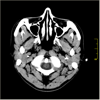

In [78]:
# C:\Users\jeff1\OneDrive\Escritorio\IA-2022_1\datos_cerebros\paciente 1\1\
img = Image.open('./datos_cerebros/paciente 1/1/Paciente1CC-27-10-1988- CT from 18-01-2011 S0 I1.BMP')
img = img.resize((100, 100))
display(img)

In [79]:
mat = np.asarray(img)
print(mat.shape)
# print(mat[0].shape)
print(mat[0][0])

(100, 100, 3)
[80 78 71]


In [80]:
# https://www.geeksforgeeks.org/calculate-the-euclidean-distance-using-numpy/
def euclidean(x1, x2):
    return distance.euclidean(x1, x2)

def chebychev(x1, x2):
    return distance.chebyshev(x1, x2)

def manhattan(x1, x2):
    return distance.cityblock(x1, x2)

In [81]:
# https://neptune.ai/blog/k-means-clustering
def rand_centroids(data, k, distance):
    r, c = data.shape
    c_idx = np.random.choice(r, k)
    return data.iloc[c_idx].to_numpy()

def plus_plus(data, k, distance):
    centroids = [ data.sample(n=1).to_numpy().tolist()[0] ]
    for _ in range(k-1):
        new_c = ([],-1)         # centroid, distance to c
        for i in range(len(data)):
            x_i = data.iloc[i].to_numpy().tolist()
            if x_i not in centroids:
                d = 0
                for c in centroids:
                    d += pow(distance(c, x_i), 2)
                d /= len(centroids)
                new_c = (x_i, d) if new_c[1] < d else new_c
        centroids.append(new_c[0])
    return np.matrix(centroids)    

In [82]:
x, y, z = mat.shape

In [83]:
pixels = [list(mat[i][j]) + [i, j] for i in range(len(mat)) for j in range(len(mat[i])) ]
pixels = pd.DataFrame(pixels, columns=['R', 'G', 'B', 'i', 'j'])
pixels

,R,G,B,i,j
0,80,78,71,0,0
1,47,46,41,0,1
2,47,46,42,0,2
3,47,46,42,0,3
4,47,46,42,0,4
...,...,...,...,...,...
9995,-122,-123,127,99,95
9996,-122,-123,127,99,96
9997,-122,-123,127,99,97
9998,-122,-123,126,99,98


In [84]:
class K_Means():
    def __init__(self, n, distance=euclidean, cc=rand_centroids):
        self.data = None
        self.n = n          # n° centroids
        self.K = None
        self.d = distance
        self.cc = cc        # centroid criteria

    def new_centroids(self, idx):
        new_K = [[] for _ in self.K]

        for i in range(len(self.K)):
            # obtener indices de todos los elementos pertenecientes al cluster i de la lista de indeices
            idx_curr_cluster = idx[idx['cluster'] == i]['idx'].to_list()
            # obtener elementos correspondientes al cluster i
            cluster_i_data = self.data.loc[idx_curr_cluster]
            
            if cluster_i_data.empty:
                new_K[i] = self.K[i]
            else:
                new_K[i] = self.data.loc[idx_curr_cluster].mean().to_numpy()
            
        return np.array(new_K, dtype=object)

    def label(self):
        """
        for each row of DataFrame 
            generate 3-tuple for each cluster
                [(row_id, cluster_i, distance), ...]
            get 2-tuple with the minimun distance
                (row_id, cluster_i)
        trasform list [(row_id, cluster_i), ...] to DataFrame and return it
        """
        idx = [
                min([(idx, i, self.d(self.K[i], self.data.iloc[idx].to_numpy())) for i in range(len(self.K))], key=itemgetter(2))[:-1] 
                for idx in range(len(self.data))
            ]
        return pd.DataFrame(idx, columns=['idx', 'cluster'])  

    def execute(self, d):
        self.data = d
        new_K = self.cc(self.data, self.n, self.d)

        i = 0
        idx = None
        while not (self.K == new_K).all():
            self.K = new_K
            idx = self.label()
            new_K = self.new_centroids(idx)
            print(new_K)
            time.sleep(5)
            i += 1
        print(f'\titerations {i}')
        return new_K, idx

In [85]:
K = 4
data = pixels.copy()
data.loc[:, ['R', 'G', 'B']]

,R,G,B
0,80,78,71
1,47,46,41
2,47,46,42
3,47,46,42
4,47,46,42
...,...,...,...
9995,-122,-123,127
9996,-122,-123,127
9997,-122,-123,127
9998,-122,-123,126


In [86]:
k = K_Means(K, cc=plus_plus)

In [87]:
kernels, clusters = k.execute(data)
# clusters.to_csv('./clusters_idx.csv')

[[-1.1520605112154407 -1.2033124673969744 4.8625456442357855
  47.809598330725095 50.43453312467397]
 [92.735368956743 92.735368956743 92.18320610687023 46.98218829516539
  62.55979643765903]
 [-104.44927536231884 -104.45144927536232 -104.46231884057971
  56.25289855072464 46.35072463768116]
 [93.94454382826476 93.94096601073345 93.92844364937388 57.7871198568873
  35.2737030411449]]
[[-1.0395864508230173 -1.0855665895796491 5.3006393687933615
  47.626581417494215 50.80601278737587]
 [84.32727272727273 84.31111111111112 83.38787878787879
  46.086868686868684 61.717171717171716]
 [-100.70464963981664 -100.70726915520629 -100.72233136869679
  54.958087753765554 46.222003929273086]
 [88.77511961722487 88.69856459330144 88.39393939393939
  60.866028708133975 32.526315789473685]]
[[-2.2518186905428093 -2.2793788472299945 4.375629546726357
  48.34219362059317 51.225097929490765]
 [71.93645990922845 71.78819969742814 70.45990922844176 39.75642965204236
  56.78517397881997]
 [-100.381262199089

In [88]:
# clusters = pd.read_csv('./clusters_idx.csv')
pixels['clusters'] = clusters['cluster']
pixels.head()

,R,G,B,i,j,clusters
0,80,78,71,0,0,1
1,47,46,41,0,1,1
2,47,46,42,0,2,1
3,47,46,42,0,3,1
4,47,46,42,0,4,1


In [89]:
colors = ['r', 'g', 'b', 'y', 'b']

In [90]:
m = np.zeros((100, 100)).astype(int)
for _ in range(len(pixels)):
    row = pixels.iloc[_]
    m[row['i'], row['j']] = row['clusters']
m


array([[1, 1, 1, ..., 1, 1, 2],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [2, 0, 0, ..., 0, 0, 2]])

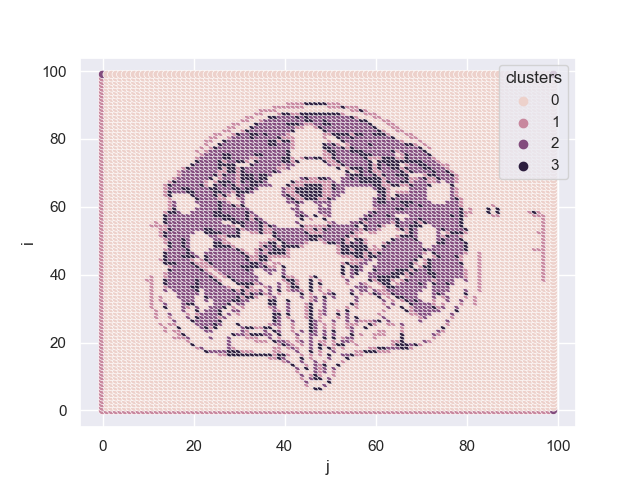

In [110]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

sns.set(style = "darkgrid")

fig = plt.figure()
ax = fig.add_subplot()

x = pixels['i']
y = pixels['j']

# pixels[pixels['clusters'] == 1]
sns.scatterplot(data=pixels, x='j', y='i', hue='clusters')

plt.show()

In [102]:
pixels[pixels['clusters'] == 2]
pixels['k'] = 1
pixels.head()

,R,G,B,i,j,clusters,k
0,80,78,71,0,0,1,1
1,47,46,41,0,1,1,1
2,47,46,42,0,2,1,1
3,47,46,42,0,3,1,1
4,47,46,42,0,4,1,1


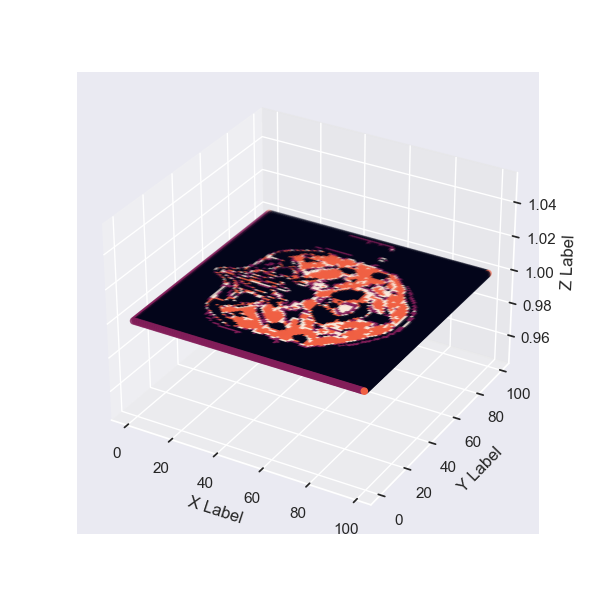

In [109]:
fig = plt.figure(figsize=(6,6))

plt.clf()
ax = fig.add_subplot(111, projection='3d') # Method 2

x = pixels['i']
y = pixels['j']
z = pixels['k']

ax.scatter(x, y, z, c=pixels['clusters'], marker='o')
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
plt.show()